## Puffin FANTOM CAGE signal analysis

This section evaluates whether CTCF-free boundary-optimized sequences show changes in predicted transcriptional activity compared to the original genomic sequences.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, wilcoxon
from pathlib import Path

In [2]:
PUFFIN_BASE   = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries_no_ctcf/results")
PUFFIN_ORIG   = PUFFIN_BASE / "puffin_original"
PUFFIN_OPT    = PUFFIN_BASE / "puffin_optimized"
SUCCESS_TSV   = PUFFIN_BASE / "successful_optimization.tsv"
TSS_TSV = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries_no_ctcf/puffin_mouse_TSSs/tss_pro_cap_max_signal.tsv")
PLOTS_DIR = Path("./../plots/")

BIN_SIZE         = 2048

FLANK         = (100_000 - BIN_SIZE) // 2   # same as in FASTA saving step

In [3]:
# Load successful optimizations
success_df = pd.read_csv(SUCCESS_TSV, sep="\t")

## Read puffin predictions

In [4]:
max_before        = []
max_after         = []

mean_diffs_f      = []
max_diffs_f       = []
mean_signed_diffs_f = []
max_signed_diffs_f  = []
correlations_f    = []
all_diffs_f       = []
pvals_f           = []

mean_diffs_r      = []
max_diffs_r       = []
mean_signed_diffs_r = []
max_signed_diffs_r  = []
correlations_r    = []
all_diffs_r       = []
pvals_r           = []

for _, row in success_df.iterrows():
    chrom          = row["chrom"]
    centered_start = int(row["centered_start"])
    centered_end   = int(row["centered_end"])
    stem           = f"{chrom}_{centered_start}_{centered_end}"

    orig = np.load(PUFFIN_ORIG / f"{stem}_original.npy")
    orig_f = orig[0, 0, FLANK:-FLANK]
    orig_r = orig[0, 9, FLANK:-FLANK]

    opt = np.load(PUFFIN_OPT / f"{stem}_optimized.npy")
    opt_f = opt[0, 0, FLANK:-FLANK]
    opt_r = opt[0, 9, FLANK:-FLANK]

    max_before.append(max(np.max(orig_f), np.max(orig_r)))
    max_after.append(max(np.max(opt_f),  np.max(opt_r)))

    # Forward strand
    diff_f = opt_f - orig_f
    all_diffs_f.append(diff_f)
    mean_diffs_f.append(np.mean(np.abs(diff_f)))
    max_diffs_f.append(np.max(np.abs(diff_f)))
    mean_signed_diffs_f.append(np.mean(diff_f))
    max_signed_diffs_f.append(np.max(diff_f))
    correlations_f.append(pearsonr(orig_f, opt_f)[0])
    _, pval_f = wilcoxon(orig_f, opt_f)
    pvals_f.append(pval_f)

    # Reverse strand
    diff_r = opt_r - orig_r
    all_diffs_r.append(diff_r)
    mean_diffs_r.append(np.mean(np.abs(diff_r)))
    max_diffs_r.append(np.max(np.abs(diff_r)))
    mean_signed_diffs_r.append(np.mean(diff_r))
    max_signed_diffs_r.append(np.max(diff_r))
    correlations_r.append(pearsonr(orig_r, opt_r)[0])
    _, pval_r = wilcoxon(orig_r, opt_r)
    pvals_r.append(pval_r)

# ── Attach results to dataframe ───────────────────────────────────────────────
success_df = success_df.assign(
    max_before          = max_before,
    max_after           = max_after,
    mean_diff_f         = mean_diffs_f,
    max_diff_f          = max_diffs_f,
    mean_signed_diff_f  = mean_signed_diffs_f,
    max_signed_diff_f   = max_signed_diffs_f,
    corr_f              = correlations_f,
    pval_f              = pvals_f,
    mean_diff_r         = mean_diffs_r,
    max_diff_r          = max_diffs_r,
    mean_signed_diff_r  = mean_signed_diffs_r,
    max_signed_diff_r   = max_signed_diffs_r,
    corr_r              = correlations_r,
    pval_r              = pvals_r,
)

print(f"Loaded puffin predictions for {len(success_df)} sequences")


Loaded puffin predictions for 178 sequences


## ECDF plot

In [5]:
# GRO-cap predictions for 51k mouse TSSs
tss_df  = pd.read_csv(TSS_TSV, sep="\t")

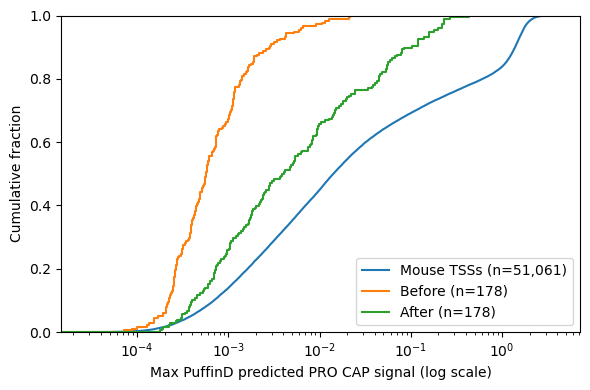

In [6]:
# ── ECDF plot ─────────────────────────────────────────────────────────────────
n = len(success_df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.ecdfplot(tss_df["max_signal"],     label=f"Mouse TSSs (n={len(tss_df):,})", ax=ax)
sns.ecdfplot(success_df["max_before"], label=f"Before (n={n})", ax=ax)
sns.ecdfplot(success_df["max_after"],  label=f"After (n={n})",  ax=ax)

ax.set_xscale("log")
ax.set_xlabel("Max PuffinD predicted PRO CAP signal (log scale)")
ax.set_ylabel("Cumulative fraction")
ax.legend()
plt.tight_layout()
plt.show()